<a href="https://colab.research.google.com/github/MAngelica-Sandoval/Proyecto-Analisis-de-Datos-NORM/blob/main/sesiones_practicas/sp_5_Maria_Sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---

## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>


**1.1** Preparación y Creación del DataFrame

In [16]:
import pandas as pd
import numpy as np
import unicodedata

df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

print("DataFrame Original:")
print(df)

DataFrame Original:
  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    Ana  25.0    Bogotá   3500.0   2023-01-01
1   Luis   NaN  Medellín   4800.0   2023-01-05
2  Pedro  35.0      None      NaN         None
3   None  29.0  Medellín   5200.0   2023-01-10
4  Marta  -5.0      Cali   5100.0   2023-01-12
5   Luis  25.0    Bogotá      NaN         None
6  Sofía   NaN      Cali   4700.0   2023-01-15


**1.2** Limpieza de Texto.

Elimino las tildes, convierto las mayúsculas a minúsculas y quito los espacios en blanco para que los datos sean comparables.

In [ ]:
def limpiar_texto(texto):
    if pd.isna(texto):
        return np.nan
    # Quitar tildes
    texto = unicodedata.normalize('NFD', str(texto))
    texto = "".join(c for c in texto if unicodedata.category(c) != 'Mn')
    # Minúsculas y quitar espacios laterales
    return texto.lower().strip()

df['Nombre'] = df['Nombre'].apply(limpiar_texto)
df['Ciudad'] = df['Ciudad'].apply(limpiar_texto)

print("Texto normalizado:")
print(df)

Texto normalizado:
  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    ana  25.0    bogota   3500.0   2023-01-01
1   luis   NaN  medellin   4800.0   2023-01-05
2  pedro  35.0       NaN      NaN         None
3    NaN  29.0  medellin   5200.0   2023-01-10
4  marta  -5.0      cali   5100.0   2023-01-12
5   luis  25.0    bogota      NaN         None
6  sofia   NaN      cali   4700.0   2023-01-15


**1.3 ** Eliminación de Registros Incompletos (en el Caso Pedro)

 Elimino a "Pedro" (que es el índice 2) porque no tiene información en los campos Ciudad, Ingreso y Fecha, por lo que es un registro poco útil para el análisis.

In [ ]:
# Eliminar la fila de Pedro (índice 2)
df = df.drop(index=2).reset_index(drop=True)

print("DataFrame tras eliminar a Pedro:")
print(df)

DataFrame tras eliminar a Pedro:
  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    ana  25.0    bogota   3500.0   2023-01-01
1   luis   NaN  medellin   4800.0   2023-01-05
2    NaN  29.0  medellin   5200.0   2023-01-10
3  marta  -5.0      cali   5100.0   2023-01-12
4   luis  25.0    bogota      NaN         None
5  sofia   NaN      cali   4700.0   2023-01-15


**1.4 ** Tratamiento de Errores Lógicos e Imputación de Edad

 Identifico valores imposibles (edad negativa de Marta) y los convierto en NaN. Luego, calculo la mediana de la columna y la uso para completar todos los datos faltantes en la columna Edad.

In [ ]:
# 1. Convertir edad negativa en NaN
df.loc[df['Edad'] < 0, 'Edad'] = np.nan

# 2. Calcular la mediana de la columna Edad
mediana_edad = df['Edad'].median()

# 3. Imputar los NaN con la mediana calculada
df['Edad'] = df['Edad'].fillna(mediana_edad)

# 4. Ajustar formato de FechaIngreso para que los vacíos se vean como NaN
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')
df['FechaIngreso'] = df['FechaIngreso'].astype(object).where(df['FechaIngreso'].notnull(), np.nan)

print(f"Mediana calculada para imputación: {mediana_edad}")
print("\nDataFrame con Edades corregidas e imputadas:")
print(df)

Mediana calculada para imputación: 25.0

DataFrame con Edades corregidas e imputadas:
  Nombre  Edad    Ciudad  Ingreso         FechaIngreso
0    ana  25.0    bogota   3500.0  2023-01-01 00:00:00
1   luis  25.0  medellin   4800.0  2023-01-05 00:00:00
2    NaN  29.0  medellin   5200.0  2023-01-10 00:00:00
3  marta  25.0      cali   5100.0  2023-01-12 00:00:00
4   luis  25.0    bogota      NaN                  NaN
5  sofia  25.0      cali   4700.0  2023-01-15 00:00:00


**1.5** Imputación de Ingresos y Nombre.

 Dado que eliminé a Pedro, la columna Ciudad ya está completa. Ahora procedemos a rellenar los vacíos en Ingreso utilizando la mediana y renombramos el valor faltante en Nombre con desconocido.

In [ ]:
# 1. Calcular la mediana de los ingresos
mediana_ingreso = df['Ingreso'].median()

# 2. Imputar los NaN en la columna Ingreso
df['Ingreso'] = df['Ingreso'].fillna(mediana_ingreso)

# 3. Rellenar el nombre faltante (fila 2, antes fila 3) como 'desconocido'
df['Nombre'] = df['Nombre'].fillna('desconocido')

print(f"Mediana de ingresos aplicada: {mediana_ingreso}")

Mediana de ingresos aplicada: 4800.0


**1.6 **Conversión Final de Fechas e Informe de Resultados

Como paso final,convierto la columna FechaIngreso al tipo de dato datetime. Los valores que eran NaN se convierten automáticamente en NaT (Not a Time), que es el estándar para representar fechas ausentes de forma que no rompan los cálculos temporales.

In [ ]:
# Convertir None en NaN
df['FechaIngreso'] = df['FechaIngreso'].replace({None: np.nan})

# Rellenar con la fecha antigua (ESTO ES LO QUE QUIERES VER)
df['FechaIngreso'] = df['FechaIngreso'].fillna('1900-01-01')

# Transformar a datetime
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')

# Opcional: Quitar las horas para que se vea limpio
df['FechaIngreso'] = df['FechaIngreso'].dt.date
print(df)

        Nombre  Edad    Ciudad  Ingreso FechaIngreso
0          ana  25.0    bogota   3500.0   2023-01-01
1         luis  25.0  medellin   4800.0   2023-01-05
2  desconocido  29.0  medellin   5200.0   2023-01-10
3        marta  25.0      cali   5100.0   2023-01-12
4         luis  25.0    bogota   4800.0   1900-01-01
5        sofia  25.0      cali   4700.0   2023-01-15


## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>


In [8]:

import pandas as pd

# 1. Crear el DataFrame base
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

# Mostrar el DataFrame para verificar
print("DataFrame Original:")
print(df)
print("-" * 30)

#  Responder: ¿Cuál es el total de registros originales?
total_registros = len(df)
print(f"El total de registros originales es: {total_registros}")

DataFrame Original:
    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
2  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15
5  104  Carlos    40      Cali    2023-01-15
6  104  Carlos    41      Cali    2023-01-16
------------------------------
El total de registros originales es: 7


In [9]:
# Identificar cuáles son los registros duplicados exactos
duplicados_exactos_df = df[df.duplicated(keep=False)]

# Contar cuántos registros son duplicados exactos (filas que se repiten)
total_duplicados_exactos = df.duplicated().sum()

print("Registros que tienen duplicados exactos:")
print(duplicados_exactos_df)
print("-" * 30)
print(f"Cantidad de registros duplicados detectados (sin contar el original): {total_duplicados_exactos}")

Registros que tienen duplicados exactos:
    ID  Nombre  Edad Ciudad FechaRegistro
1  102    Luis    30   Cali    2023-01-05
2  102    Luis    30   Cali    2023-01-05
4  104  Carlos    40   Cali    2023-01-15
5  104  Carlos    40   Cali    2023-01-15
------------------------------
Cantidad de registros duplicados detectados (sin contar el original): 2


En la base de datos original, hay filas en las que todos los campos (ID, Nombre, Edad, Ciudad y Fecha) son iguales, lo cual no tiene sentido en este contexto. Por lo tanto, lo considero un error en la entrada de datos.

In [11]:
# Procedimiento: Limpieza de duplicados exactos
# Decido eliminar los registros duplicados porque consideramos que
# son errores de registro (el mismo dato ingresado dos veces por error).

# Uso drop_duplicates() sin argumentos para que evalúe todas las columnas
# keep='first' asegura que mantengamos la primera aparición y borremos las copias
df_limpio = df.drop_duplicates(keep='first')

print("Nuevo DataFrame (df_limpio) después de eliminar duplicados exactos:")
print(df_limpio)

# Verifico cuántos registros eliminamos
eliminados = len(df) - len(df_limpio)
print(f"Procedimiento realizado: Eliminamos {eliminados} registros duplicados exactos.")
print(f"Registros restantes: {len(df_limpio)}")

Nuevo DataFrame (df_limpio) después de eliminar duplicados exactos:
    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15
6  104  Carlos    41      Cali    2023-01-16
Procedimiento realizado: Eliminamos 2 registros duplicados exactos.
Registros restantes: 5


In [12]:
# Defino las columnas que deberían ser únicas (ID y Nombre)
columnas_clave = ['ID', 'Nombre']

# Identifico quiénes tienen el mismo ID y Nombre pero otros datos distintos
duplicados_por_id = df_limpio[df_limpio.duplicated(subset=columnas_clave, keep=False)]

# Cuenta cuántos registros están en esta situación
total_duplicados_id = df_limpio.duplicated(subset=columnas_clave).sum()

print("Registros con el mismo ID y Nombre (pero diferentes datos):")
print(duplicados_por_id)
print("-" * 30)
print(f"Cantidad de registros con ID duplicado: {total_duplicados_id}")

Registros con el mismo ID y Nombre (pero diferentes datos):
    ID  Nombre  Edad Ciudad FechaRegistro
4  104  Carlos    40   Cali    2023-01-15
6  104  Carlos    41   Cali    2023-01-16
------------------------------
Cantidad de registros con ID duplicado: 1


In [16]:
import pandas as pd

# 1. Crear el DataFrame base
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

# 2. Primero elimino los duplicados exactos y uso .copy()
df_limpio = df.drop_duplicates().copy()

# 3. Ahora sí convierto la fecha
df_limpio['FechaRegistro'] = pd.to_datetime(df_limpio['FechaRegistro'])

# 4. Aplico mi criterio para el caso de Carlos
# Ordeno y me quedo con el último ID (el más reciente)
df_final = df_limpio.sort_values('FechaRegistro').drop_duplicates(subset=['ID'], keep='last')

print("DataFrame Final (Sin advertencias):")
print(df_final)

DataFrame Final (Sin advertencias):
    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
6  104  Carlos    41      Cali    2023-01-16


**1.** ¿Cuál es el total de registros originales?

Al cargar el conjunto de datos inicial, identifiqué un total de 7 registros.

**2.** ¿Cuáles y cuántos son los duplicados exactos?

Encontré 2 duplicados exactos (filas donde cada columna era idéntica). Estos corresponden a una repetición de Luis (ID 102) y una de Carlos (ID 104). Procedí a eliminarlos ya que los considero errores de sistema o duplicidad en la entrada de datos.

**3.** ¿Cuáles y cuántos son los duplicados por varias columnas?

Identifiqué 1 duplicado por identidad (ID y Nombre). Se trata de Carlos (ID 104), quien aparece con 40 y 41 años en fechas distintas.

Mi hipótesis: Carlos cumplió años el 16 de enero, lo que generó un segundo registro actualizado.

Mi decisión: Aunque es información real, decidí eliminar el registro más antiguo (el de 40 años) para que mi base de datos no tenga personas repetidas y refleje la edad más reciente.

**4.** ¿Cuántos registros debo eliminar?

En total, eliminé 3 registros:
- 2 por ser duplicados exactos.

- 1 por ser un registro de identidad duplicado (el dato antiguo de Carlos).

**5.** ¿Cuántos registros quedan después de la limpieza?

Tras ejecutar mi código, el DataFrame final cuenta con 4 registros únicos, correspondientes a Ana, Luis, Marta y Carlos.

## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


In [18]:
import pandas as pd
from difflib import get_close_matches

# 1. Crear el DataFrame base
df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

# 2. Definir los nombres correctos (nuestro diccionario/lista de referencia)
ciudades_correctas = ['Bogotá', 'Cali', 'Medellín']

def estandarizar_ciudad(texto):
    # Paso A: Limpieza básica (quitar espacios y normalizar a minúsculas para comparar)
    texto = str(texto).strip().lower()

    # Paso B: Buscar la coincidencia más cercana a la lista de referencia
    # n=1 para que solo traiga la mejor, cutoff=0.6 para ser flexible con errores como 'bogata'
    coincidencia = get_close_matches(texto, [c.lower() for c in ciudades_correctas], n=1, cutoff=0.6)

    if coincidencia:
        # Si encontró algo, buscamos el formato original en ciudades_correctas
        # y lo devolvemos con la primera letra en mayúscula (.capitalize() o .title())
        idx = [c.lower() for c in ciudades_correctas].index(coincidencia[0])
        return ciudades_correctas[idx].capitalize()
    else:
        # Si no encuentra nada parecido, lo dejamos igual pero con formato título
        return texto.capitalize()

# 3. Aplicar la función usando .apply()
df['Ciudad_Limpia'] = df['Ciudad'].apply(estandarizar_ciudad)

print("Resultado de la estandarización:")
print(df)

Resultado de la estandarización:
      Ciudad Ciudad_Limpia
0     bogota        Bogotá
1     Bogotá        Bogotá
2     BOGOTA        Bogotá
3     bogotá        Bogotá
4     bogata        Bogotá
5     Bógota        Bogotá
6     BogoTa        Bogotá
7       Cali          Cali
8       calí          Cali
9   medellín      Medellín
10  medellin      Medellín


Para unificar los nombres en la columna de ciudades, utilicé la herramienta get_close_matches. Le proporcioné una lista con los nombres correctos (Bogotá, Cali, Medellín) y le pedí que buscara coincidencias; así, cuando encontraba errores como 'bogata' o 'calí', los corregía basándose en los nombres correctos. Luego, usé el comando apply para aplicar automáticamente estos cambios en todas las filas, asegurando que todos los nombres estuvieran bien escritos y con la primera letra en mayúscula.

## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.

2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
- **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).

**Rta:** MCAR,  Los datos faltan de forma totalmente aleatoria sin depender de ninguna otra variable, por lo que no hay un patrón que explique la ausencia.

- **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

**Rta:**  MAR, la falta de datos sobre las horas de estudio depende de una variable que sí conocemos y que está registrada en la base de datos (el promedio académico).

- **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

 **Rta:** MAR, al igual que el anterior, la probabilidad de que el dato falte está ligada a la variable observada "promedio", permitiendo modelar el patrón de ausencia.

- **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.

 **Rta:** MAR, el dato faltante en el promedio está relacionado con la variable observada "género", por lo que la ausencia se puede explicar con la información disponible.

- **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.

**Rta:** MNAR, la ausencia depende del propio valor que falta (pocas horas de estudio), ya que los estudiantes ocultan el dato precisamente porque ese valor es bajo.

## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

In [17]:
import pandas as pd
import numpy as np

# 1. Configuración de la semilla para que nos den los mismos resultados
np.random.seed(42)
n = 30

# 2. Creación del DataFrame base
df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# 3. Introducción manual de valores faltantes (NaN)
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

# 4. Análisis: ¿Qué variables tienen mayor proporción de datos faltantes?
faltantes = df.isnull().sum()
proporcion = (df.isnull().sum() / len(df)) * 100

# Creamos una tablita para verlo mejor
analisis_faltantes = pd.DataFrame({
    'Cantidad Faltantes': faltantes,
    'Proporción (%)': proporcion
})

print("Análisis de datos faltantes por variable:")
print(analisis_faltantes.sort_values(by='Proporción (%)', ascending=False))

Análisis de datos faltantes por variable:
                    Cantidad Faltantes  Proporción (%)
Promedio                             4       13.333333
Horas_estudio                        4       13.333333
Ingreso_familiar                     3       10.000000
Edad                                 0        0.000000
Semestres_cursados                   0        0.000000


<Figure size 1000x600 with 0 Axes>

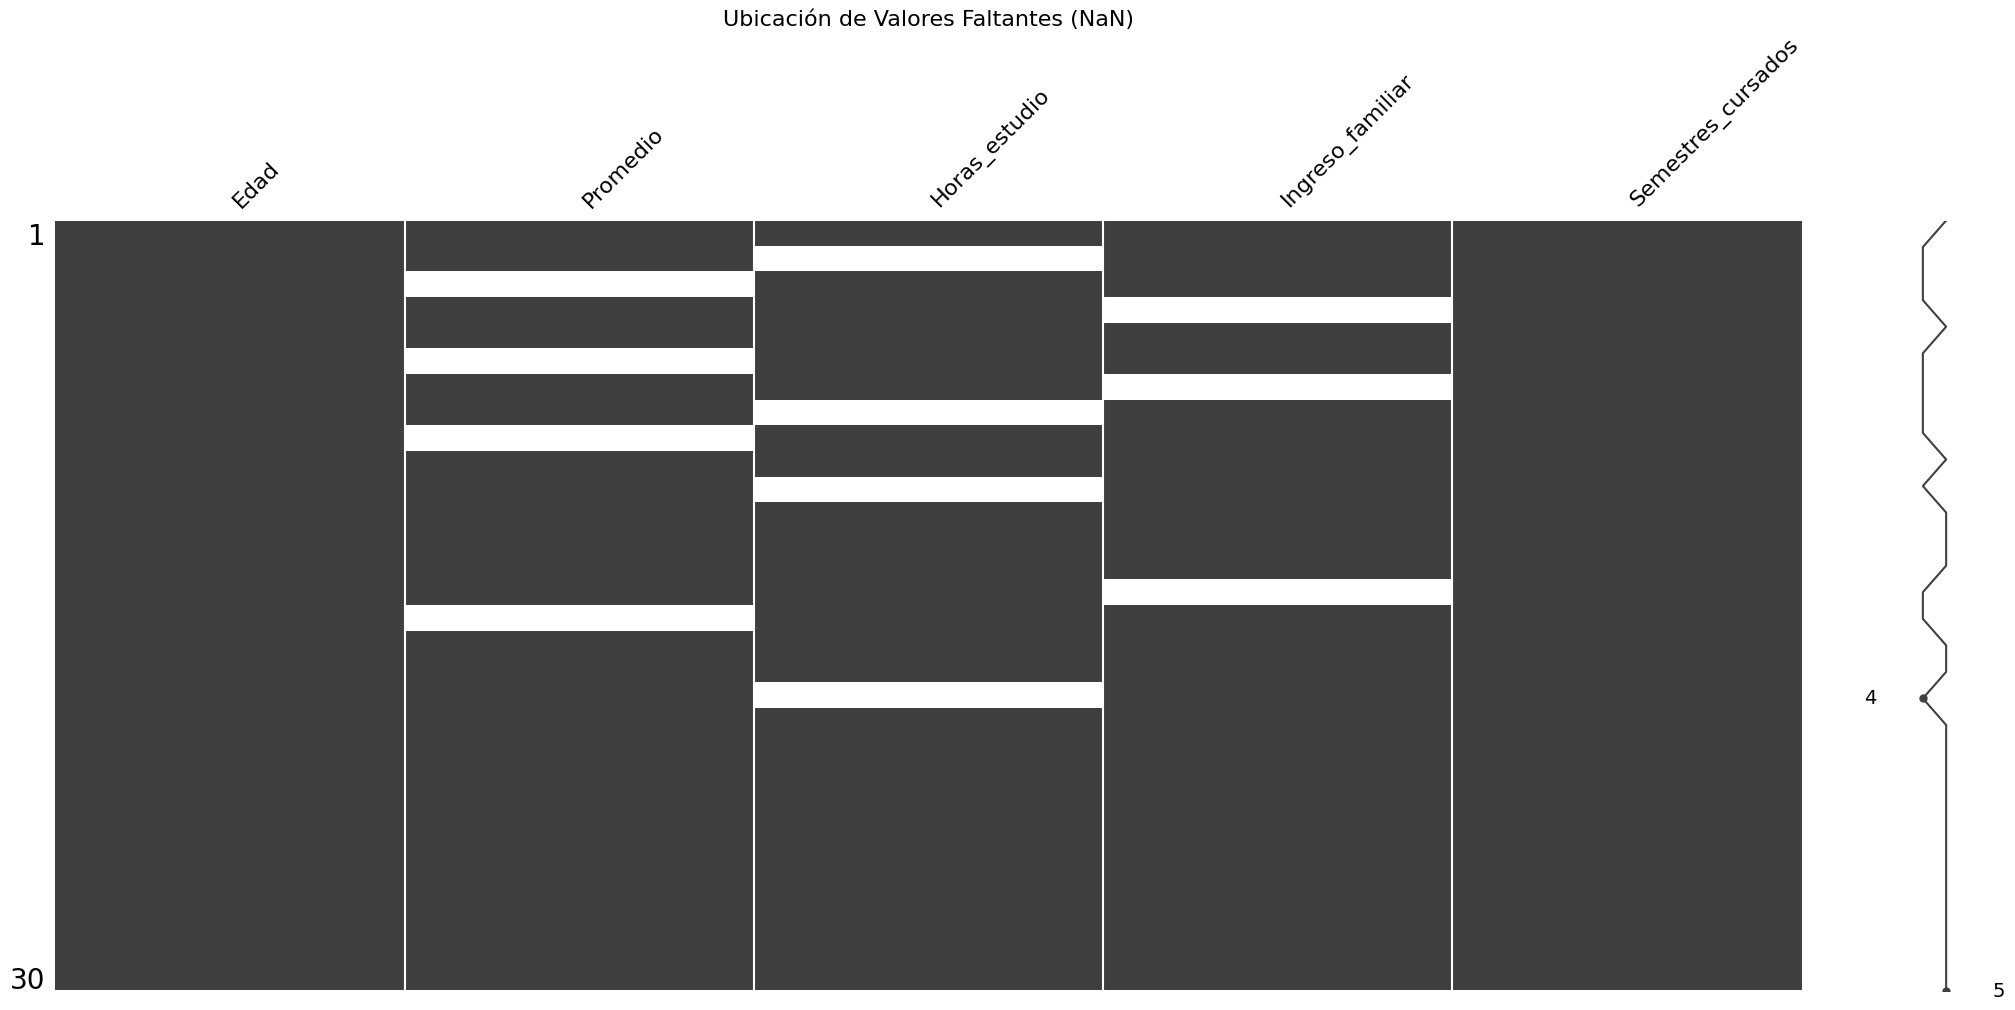

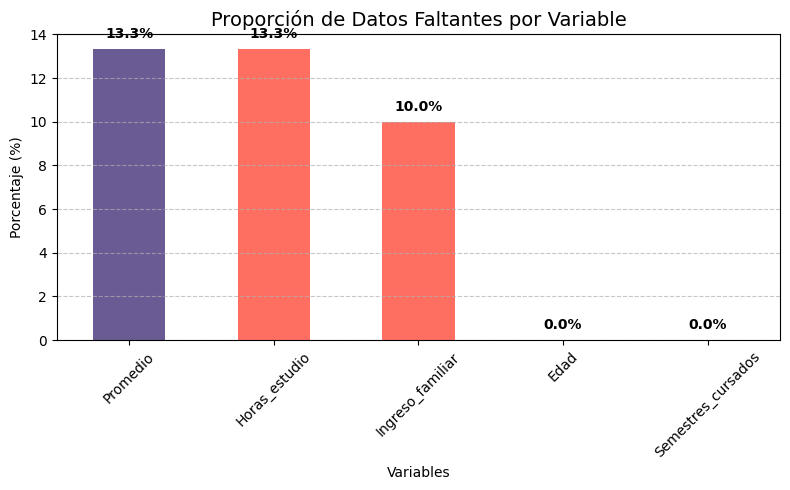

In [18]:
import matplotlib.pyplot as plt
import missingno as msno

# --- Gráfica 1: Matriz de Nulidad ---
# Esta gráfica muestra las líneas blancas donde faltan datos.
plt.figure(figsize=(10, 6))
msno.matrix(df)
plt.title("Ubicación de Valores Faltantes (NaN)", fontsize=16)
plt.show()

# --- Gráfica 2: Proporción de Faltantes (Barras) ---
plt.figure(figsize=(8, 5))
colores = ['#FF6F61' if x > 0 else '#6B5B95' for x in analisis_faltantes['Cantidad Faltantes']]

analisis_faltantes['Proporción (%)'].sort_values(ascending=False).plot(kind='bar', color=colores)

plt.title("Proporción de Datos Faltantes por Variable", fontsize=14)
plt.ylabel("Porcentaje (%)")
plt.xlabel("Variables")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de texto sobre las barras
for i, v in enumerate(analisis_faltantes['Proporción (%)'].sort_values(ascending=False)):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**¿Observas algún patrón estructurado o parecen aleatorios?**

Al analizar la distribución de los valores nulos en el DataFrame y las gráficas de nulidad, concluyo que no existe un patrón definido y los datos parecen distribuidos aleatoriamente, identificándose como un mecanismo MCAR.

 En la matriz de visualización, las líneas blancas están dispersas y no están alineadas entre columnas, lo que confirma que la ausencia de datos en una variable no depende de otras ni sigue un patrón lógico, evidenciando una completa independencia en la pérdida de información.

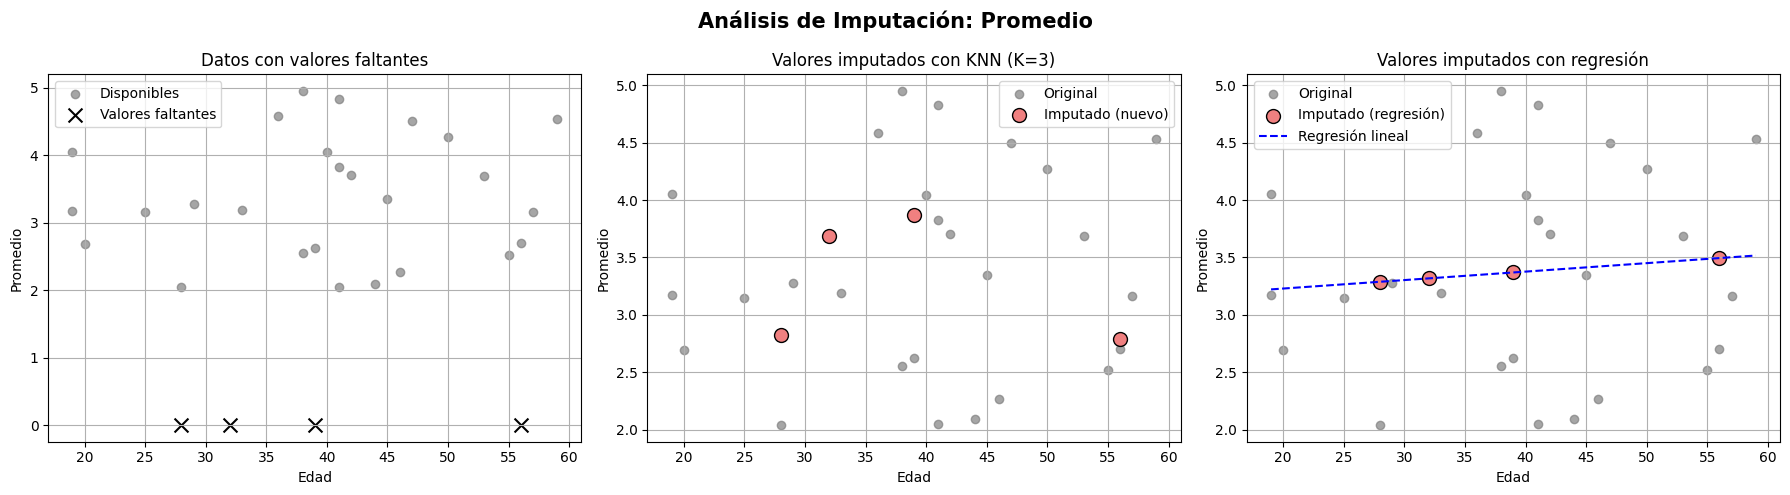

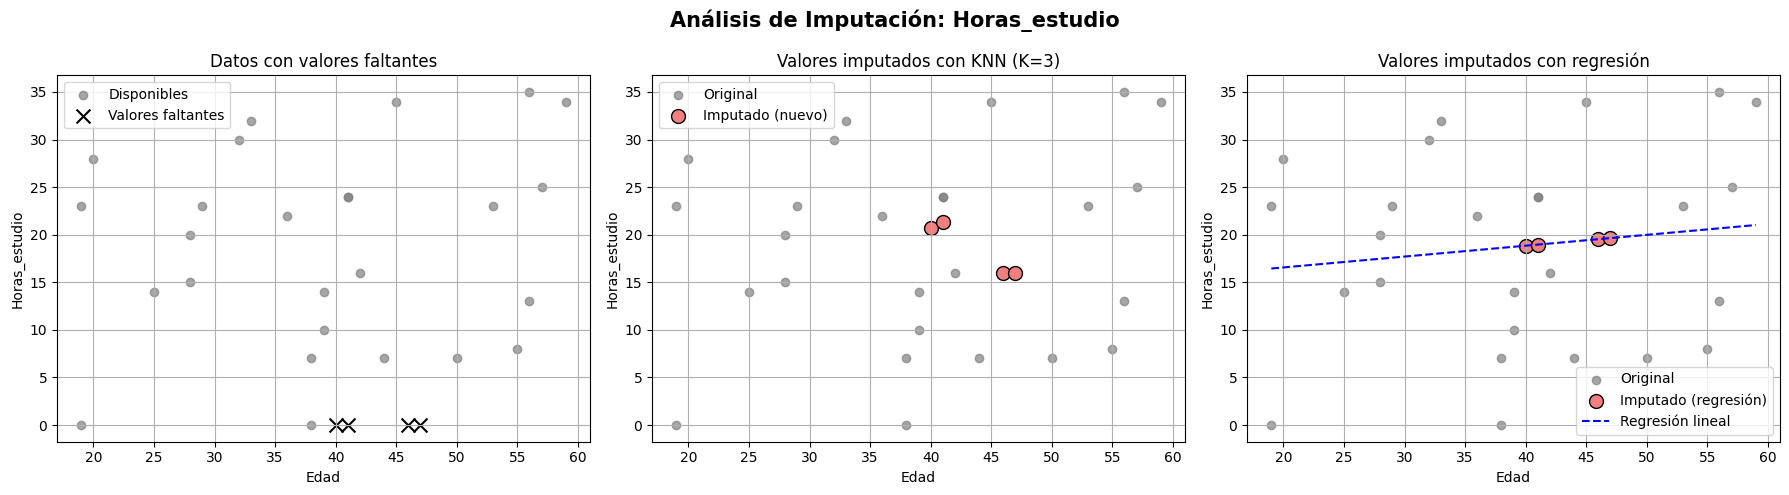

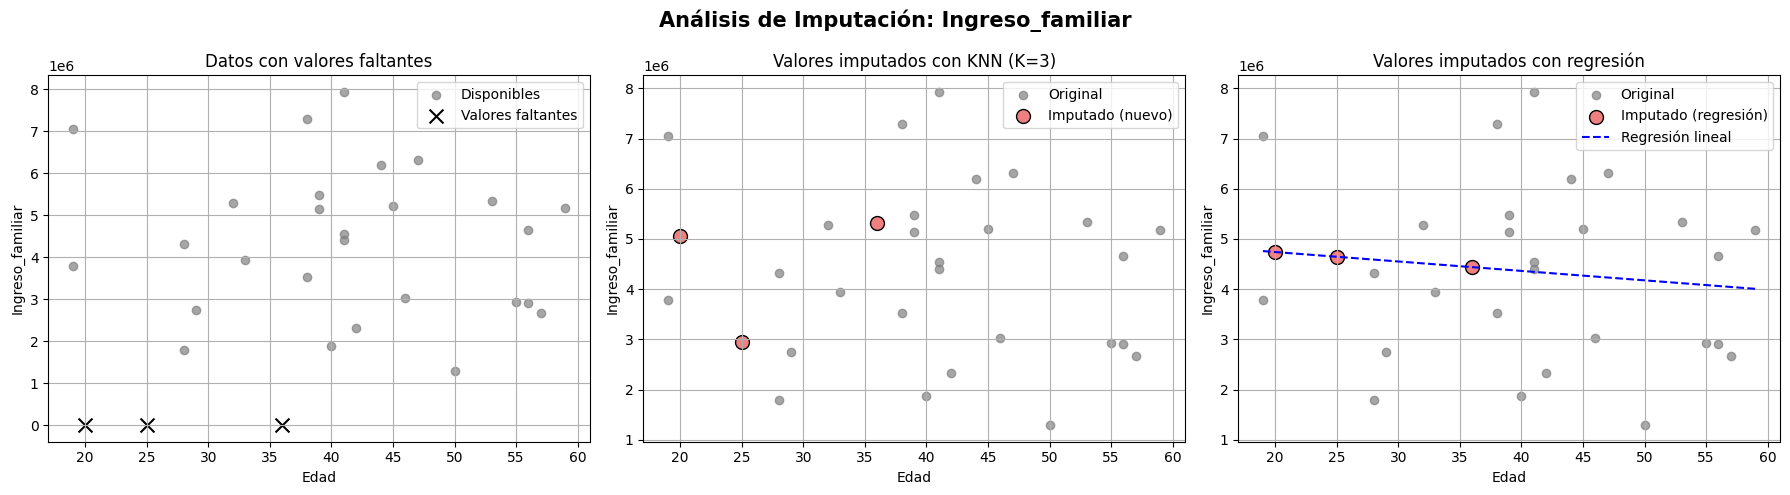

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

# 1. Dataset base
np.random.seed(42)
n = 30
df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de faltantes
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

# Lista de variables a procesar
variables = ['Promedio', 'Horas_estudio', 'Ingreso_familiar']

for var in variables:
    mask_missing = df[var].isnull()

    # --- Imputación KNN---
    imputer = KNNImputer(n_neighbors=3)
    # Imputamos usando Edad e Ingreso (o la variable actual)
    data_knn = pd.DataFrame(imputer.fit_transform(df[['Edad', var]]), columns=['Edad', var])

    # --- Imputación Regresión---
    X_train = df.loc[~mask_missing, ['Edad']]
    y_train = df.loc[~mask_missing, var]
    X_missing = df.loc[mask_missing, ['Edad']]

    reg = LinearRegression()
    reg.fit(X_train, y_train)
    df_reg_val = reg.predict(X_missing)

    # --- GENERACIÓN DE PANELES ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Análisis de Imputación: {var}', fontsize=15, fontweight='bold')

    # PANEL 1: Datos faltantes
    axes[0].scatter(df.loc[~mask_missing, "Edad"], df.loc[~mask_missing, var], color="gray", alpha=0.7, label="Disponibles")
    axes[0].scatter(df.loc[mask_missing, "Edad"], [0]*mask_missing.sum(), marker="x", color="black", s=100, label="Valores faltantes")
    axes[0].set_title("Datos con valores faltantes")
    axes[0].legend()

    # PANEL 2: Imputación KNN
    axes[1].scatter(data_knn.loc[~mask_missing, "Edad"], data_knn.loc[~mask_missing, var], color="gray", alpha=0.7, label="Original")
    axes[1].scatter(data_knn.loc[mask_missing, "Edad"], data_knn.loc[mask_missing, var], color="lightcoral", edgecolors="black", s=100, label="Imputado (nuevo)")
    axes[1].set_title(f"Valores imputados con KNN (K=3)")
    axes[1].legend()

    # PANEL 3: Imputación Regresión
    axes[2].scatter(df.loc[~mask_missing, "Edad"], df.loc[~mask_missing, var], color="gray", alpha=0.7, label="Original")
    axes[2].scatter(df.loc[mask_missing, "Edad"], df_reg_val, color="lightcoral", edgecolors="black", s=100, label="Imputado (regresión)")
    # Línea de regresión
    x_line = np.linspace(df["Edad"].min(), df["Edad"].max(), 100).reshape(-1,1)
    y_line = reg.predict(pd.DataFrame(x_line, columns=['Edad']))
    axes[2].plot(x_line, y_line, color="blue", linestyle="--", label="Regresión lineal")
    axes[2].set_title("Valores imputados con regresión")
    axes[2].legend()

    for ax in axes:
        ax.set_xlabel("Edad")
        ax.set_ylabel(var)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

Al comparar los resultados de las graficas, puedo concluir lo siguiente:

1. Imputación con KNN (K=3) : lo que observo es que KNN es la técnica que mejor mantiene la esencia de los datos. Al analizar los paneles centrales de las tres variables, los puntos rojos (imputados) se integran de manera natural con la masa de puntos grises.

Como la técnica se fundamenta en la similitud entre estudiantes (o sus vecinos más cercanos), esta técnica conserva la dispersión y el desorden natural del grupo real. No crea una lógica estricta; simplemente supone que si dos personas tienen edades similares, sus promedios o ingresos también deberían ser parecidos, respetando la diversidad de la muestra.

2. Imputación por Regresión
Por el contrario, en la regresión lineal observó que altera la naturaleza de los datos. En los paneles de la derecha, se ve claramente cómo los puntos rojos caen todos exactamente sobre la línea punteada azul.

Aunque en la vida real, es casi imposible que el ingreso o las horas de estudio de una persona sigan una trayectoria lineal perfecta en relación con su edad, como se muestra en la regresión. Al aplicar regresión, estamos eliminando el "ruido" y la variabilidad natural, forzando una relación matemática que, en este conjunto de datos aleatorios, en realidad no existe.

 **Conclusión Final**

Para esta tarea, opto por la imputación mediante KNN. A diferencia de la regresión, que genera un patrón "artificial" y rígido que podría alterar futuros análisis, KNN rellena los valores faltantes de manera más natural, preservando la estructura original de los datos de los estudiantes.

## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

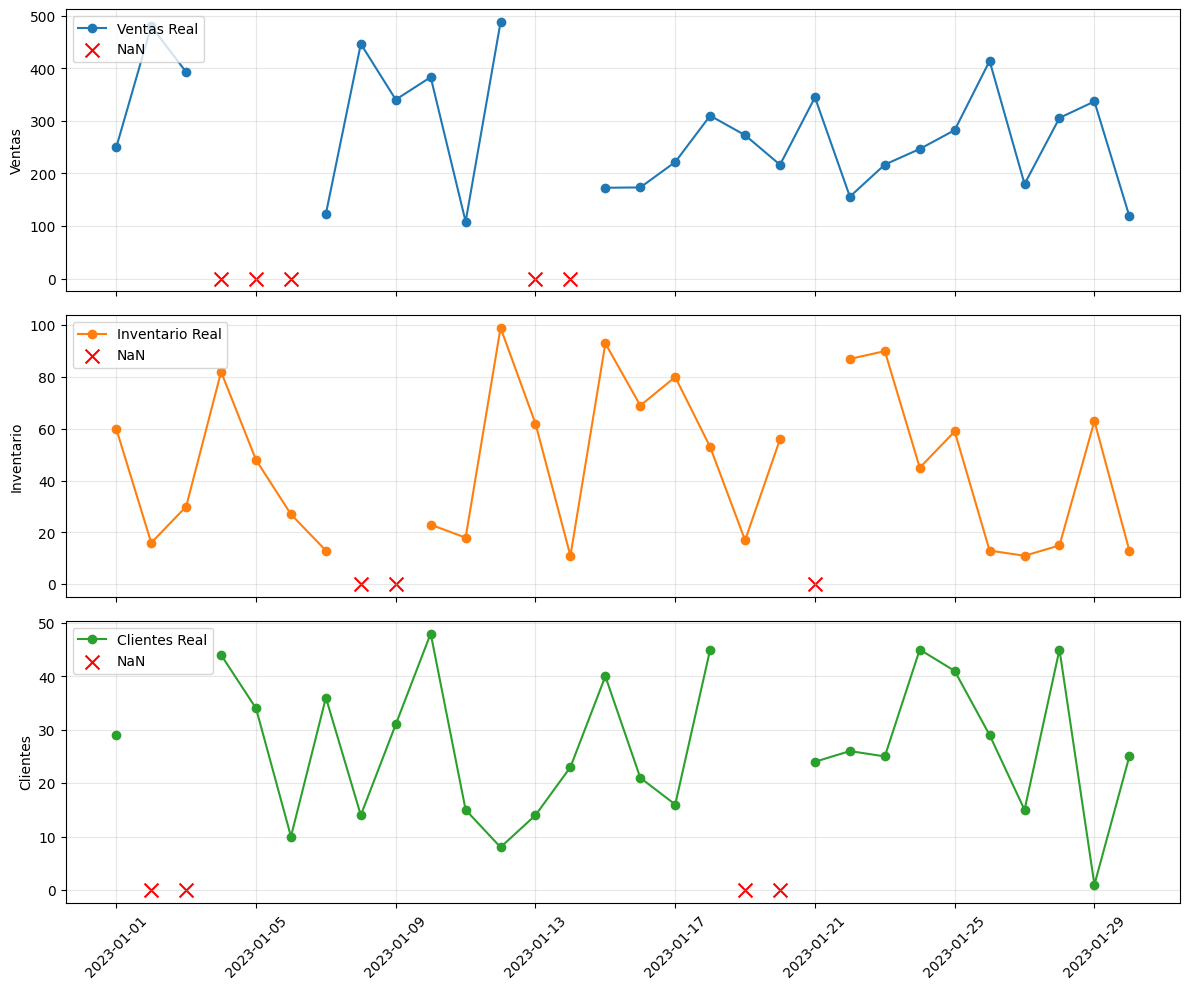

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Creación del DataFrame base
np.random.seed(42)
n = 30

df = pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)

# Visualización para el análisis del punto 2
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
variables = ['Ventas', 'Inventario', 'Clientes']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, var in enumerate(variables):
    axes[i].plot(df['Fecha'], df[var], marker='o', linestyle='-', color=colores[i], label=f'{var} Real')
    # Marcamos los NaNs en el valor 0 con una X roja
    mask = df[var].isnull()
    axes[i].scatter(df.loc[mask, 'Fecha'], [0]*mask.sum(), marker='x', color='red', s=100, label='NaN')
    axes[i].set_ylabel(var)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**2. Análisis del DataFrame de Series Temporales**

**2.1 ¿Qué variables presentan datos faltantes consecutivos? **

Al revisar las gráficas, yo observo que las tres variables tienen este problema de datos faltantes seguidos:

- Ventas: Es donde veo el vacío más grande. Tengo 5 datos faltantes en total, repartidos en dos bloques (uno de 3 días y otro de 2 días consecutivos).

- Inventario: Aquí identifico 3 días faltantes. Veo un bloque de 2 días seguidos y un día más que está solo más adelante.

- Clientes: En esta variable noto 4 datos faltantes, organizados en dos bloques de 2 días consecutivos cada uno.

**2.2 ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?**
Para mí, mantener el orden cronológico, especialmente en una serie de tiempo, es esencial en este tipo de análisis. Dado que emplearé técnicas como LOCF o NOCB, mi enfoque se centra en la continuidad de los datos. Estos métodos rellenan los valores faltantes "arrastrando" información de un punto a otro; si las fechas no están correctamente alineadas, no podré determinar a qué día corresponde cada dato ni a qué se le asigna. Esto podría comprometer la coherencia y la integridad de la información.

Si los datos estuvieran desordenados, correría el riesgo de imputar un hueco con un valor que no tenga sentido lógico. Por ejemplo, podría asignar las ventas de un domingo (normalmente bajas) a un lunes de alta actividad solo porque las filas se mezclaron.

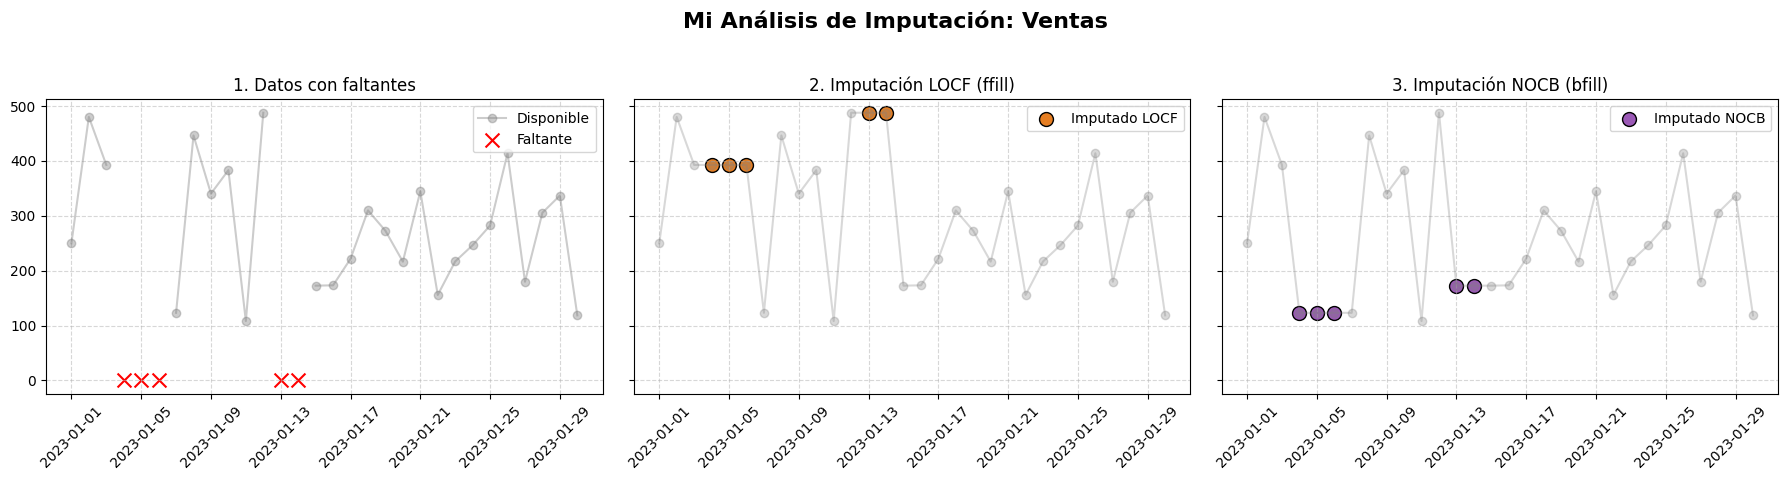

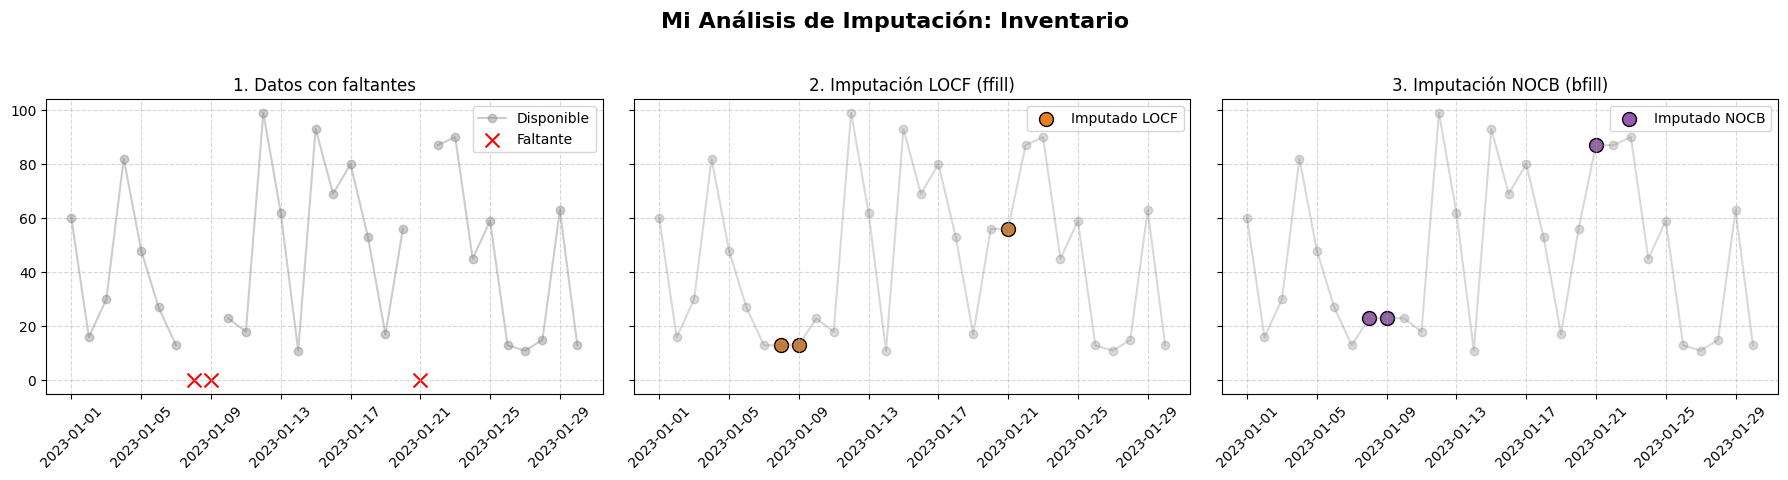

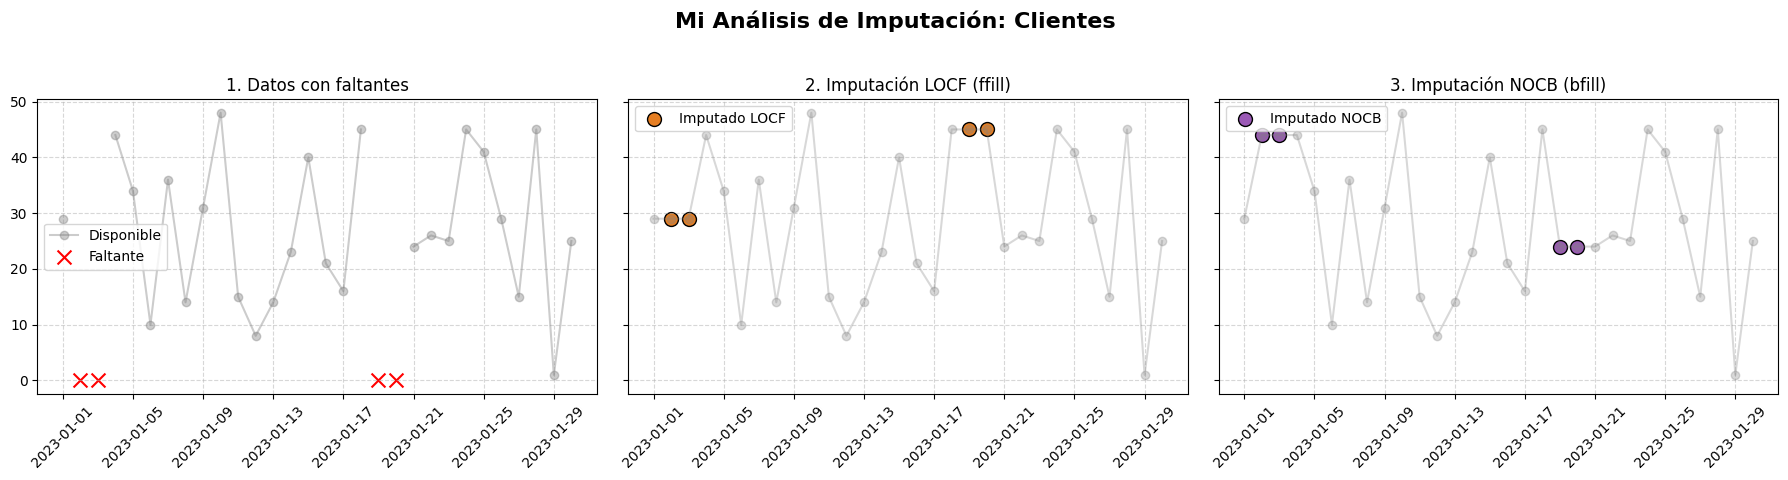

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- RECONSTRUCCIÓN DEL DATAFRAME ---
np.random.seed(42)
n = 30
df = pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)


if 'Fecha' not in df.columns:
    df = df.reset_index()

# --- PROCESO DE IMPUTACIÓN ---
# Yo realizo la imputación para todas las variables
df_locf = df.ffill() # Last Observation Carried Forward
df_nocb = df.bfill() # Next Observation Carried Backward

# --- GENERACIÓN DE PANELES VISUALES ---
variables = ['Ventas', 'Inventario', 'Clientes']
colores_imp = ['#e67e22', '#9b59b6'] # Naranja para LOCF, Morado para NOCB

for var in variables:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f'Mi Análisis de Imputación: {var}', fontsize=16, fontweight='bold')

    # Panel 1: Datos con faltantes
    axes[0].plot(df['Fecha'], df[var], marker='o', color='gray', alpha=0.4, label='Disponible')
    mask = df[var].isnull()
    # Yo ubico las X rojas en el valor 0 para marcar el hueco
    axes[0].scatter(df.loc[mask, 'Fecha'], [0]*mask.sum(), marker='x', color='red', s=100, label='Faltante')
    axes[0].set_title("1. Datos con faltantes")
    axes[0].legend()

    # Panel 2: Imputación LOCF (Dato Anterior)
    axes[1].plot(df_locf['Fecha'], df_locf[var], marker='o', color='gray', alpha=0.3)
    axes[1].scatter(df_locf.loc[mask, 'Fecha'], df_locf.loc[mask, var], color=colores_imp[0], s=100, edgecolors='black', label='Imputado LOCF')
    axes[1].set_title("2. Imputación LOCF (ffill)")
    axes[1].legend()

    # Panel 3: Imputación NOCB (Dato Posterior)
    axes[2].plot(df_nocb['Fecha'], df_nocb[var], marker='o', color='gray', alpha=0.3)
    axes[2].scatter(df_nocb.loc[mask, 'Fecha'], df_nocb.loc[mask, var], color=colores_imp[1], s=100, edgecolors='black', label='Imputado NOCB')
    axes[2].set_title("3. Imputación NOCB (bfill)")
    axes[2].legend()

    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.5)
        # Yo roto las fechas para que se lean bien
        plt.setp(ax.get_xticklabels(), rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?
Al imputar, generar y comparar los paneles de cada variable, he llegado a las siguientes conclusiones sobre cómo cada método afecta los resultados (sobreestimación o subestimación) y el impacto que esto tendría en un modelo futuro.

**A. En el caso de Ventas:** Mi elección es NOCB
Al revisar mis gráficas, veo que en los períodos faltantes, el valor anterior era alto y el siguiente era más bajo.
Si usara el método LOCF, estaría sobreestimando los ingresos y creando una falsa sensación de éxito. Para un futuro modelado financiero, yo prefiero ser conservadora y quedarme con el dato menor (NOCB). Es mejor que mi modelo trabaje con expectativas bajas a que falle por esperar un dinero que probablemente no entró.

**B. En el caso de Inventario: Mi elección es LOCF**
Prefiero el método LOCF porque, aunque puede subestimar las ventas en algunas ocasiones, prefiero que el sistema me solicite reponer productos en lugar de mostrar un stock disponible cuando en realidad la bodega está vacía. Si el inventario indica que un producto está disponible y el cliente intenta comprarlo pero no lo encuentra, pierdo la venta y la confianza del cliente. Con LOCF, me aseguro de no prometer existencias que no puedo garantizar.

**C. En el caso de Clientes: Mi elección es NOCF**

En el primer grupo de faltantes, el valor inicial era muy bajo. Si aplico LOCF, mantengo esa cifra baja durante varios días, aunque la gráfica indica que luego el flujo de personas aumentó. Prefiero usar NOCB porque refleja mejor la tendencia de crecimiento posterior. Para mí, es más útil que el análisis muestre ese incremento de clientes lo antes posible para planificar adecuadamente el personal y la atención en el local.